In [2]:
%pip install snntorch
import numpy as np
import torch
import torch.nn as nn
import numpy as np
import snntorch as snn
from snntorch import utils
from snntorch import spikegen, surrogate
import snntorch.functional as SF
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.patches as mpatches
from torch.nn.functional import cross_entropy
import torch.nn.functional as F

# -------------- Parameters -----------------------
time_steps = 39512


Note: you may need to restart the kernel to use updated packages.


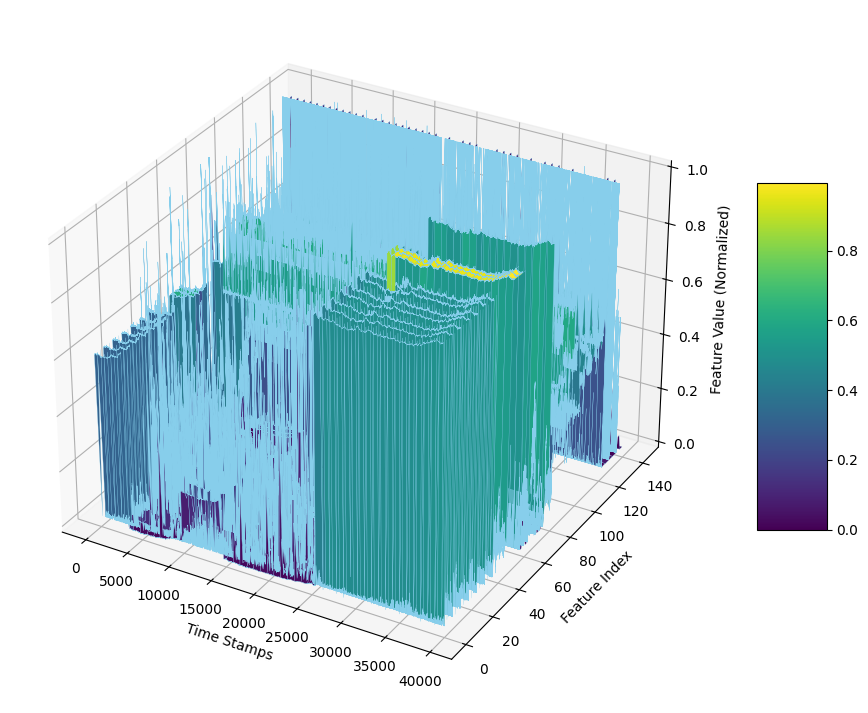

In [3]:
### Setup the training Data
# -------------- Parameters -----------------------
time_steps = 39512
train_file = "/kaggle/input/datasets/firmwired/fi-2010/data/published/BenchmarkDatasets/BenchmarkDatasets/BenchmarkDatasets/NoAuction/NoAuction_MinMax/NoAuction_MinMax_Training/Train_Dst_NoAuction_MinMax_CF_1.txt"

data = np.loadtxt(train_file)

ask_price = data[0, :]
bid_price = data[2, :]
mid_price = (ask_price + bid_price) / 2
features  = data[:144, :].T 
labels    = data[146, :].T - 1

features_tensor = torch.from_numpy(features).float()
labels_tensor = torch.from_numpy(labels).float()


spike = spikegen.delta(features_tensor, threshold=.005, padding=True, off_spike=True)
spikes_pos = torch.where(spike > 0, spike, torch.zeros_like(spike))
spikes_neg = torch.where(spike < 0, torch.abs(spike), torch.zeros_like(spike))

Z = features_tensor[:time_steps, :].numpy()

X, Y = np.meshgrid(np.arange(time_steps), np.arange(144))
Z = Z.T

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="skyblue", linewidth=.2)
ax.set_xlabel('Time Stamps')
ax.set_ylabel("Feature Index")
ax.set_zlabel("Feature Value (Normalized)")
# ax.view_init(elev=0, azim=180)
fig.colorbar(surface, shrink=.5, aspect=5)

plt.show()

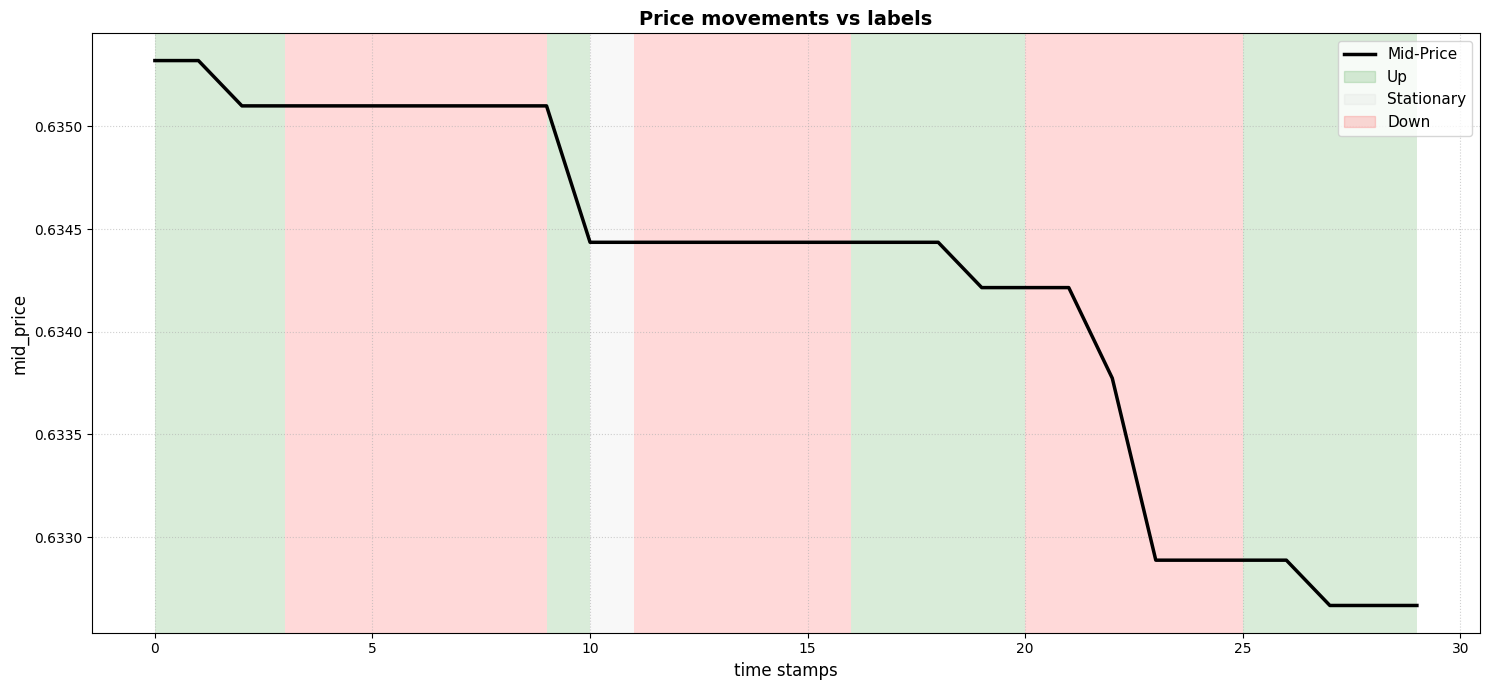

total ticks 30
class 0 12
class 1 1
class 2 17


In [4]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

test_file = "/kaggle/input/datasets/firmwired/fi-2010/data/published/BenchmarkDatasets/BenchmarkDatasets/BenchmarkDatasets/NoAuction/NoAuction_MinMax/NoAuction_MinMax_Testing/Test_Dst_NoAuction_MinMax_CF_1.txt"
data = np.loadtxt(test_file)

# extract ask/bid prices
ask_prices = data[0, :]
bid_prices = data[2, :]
raw_labels = data[146, :].astype(int) - 1
mid_prices = (ask_prices + bid_prices) / 2
start_tick = 0
end_tick = 60
prediction_horizon = 30

slice_prices = mid_prices[start_tick : end_tick - prediction_horizon]
slice_labels = raw_labels[start_tick + prediction_horizon : end_tick]

time_steps = np.arange(len(slice_prices))

plt.figure(figsize=(15, 7))

for i in range(len(time_steps) - 1):
  label = slice_labels[i]
  if label == 0:  # price up
    color = 'green'
    alpha = 0.15
  elif label == 1:  # price stable
    color = 'gray'
    alpha = 0.05
  elif label == 2:  # price down
    color = 'red'
    alpha = 0.15

  plt.axvspan(time_steps[i], time_steps[i + 1], color=color, alpha=alpha, lw=0)

plt.plot(
    time_steps,
    slice_prices,
    color='black',
    linewidth=2.5,
    label='Mid-Price',
)

plt.title("Price movements vs labels", fontsize=14, fontweight='bold')
plt.xlabel("time stamps", fontsize=12)
plt.ylabel("mid_price", fontsize=12)

up_patch = mpatches.Patch(color='green', alpha=0.15, label='Up')
flat_patch = mpatches.Patch(color='gray', alpha=0.05, label='Stationary')
down_patch = mpatches.Patch(color='red', alpha=0.15, label='Down')

plt.legend(
    handles=[
        plt.Line2D([0], [0], color='black', lw=2.5, label='Mid-Price'),
        up_patch,
        flat_patch,
        down_patch,
    ],
    fontsize=11,
)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"total ticks {len(slice_labels)}")
print(f"class 0 {np.sum(slice_labels == 0)}")
print(f"class 1 {np.sum(slice_labels == 1)}")
print(f"class 2 {np.sum(slice_labels == 2)}")

In [5]:
### Setup the Testing Data
test_data = np.loadtxt(test_file)
features_test  = test_data[:144, :].T 
labels_test    = test_data[146, :].T - 1



features_tensor_test = torch.from_numpy(features_test).float()
labels_tensor_test = torch.from_numpy(labels_test).long()


spike_test = spikegen.delta(features_tensor_test, threshold=0.005, padding=True, off_spike=True)
spikes_pos_test = torch.where(spike_test > 0, spike_test, torch.zeros_like(spike_test))
spikes_neg_test = torch.where(spike_test < 0, torch.abs(spike_test), torch.zeros_like(spike_test))

 
test_inputs = torch.cat((spikes_pos_test, spikes_neg_test), dim=1)
test_dataset = TensorDataset(test_inputs, labels_tensor_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

inputs_train = torch.cat((spikes_pos, spikes_neg), dim=1)

dataset = TensorDataset(inputs_train, labels_tensor)

batch_size = 16
# shuffle is set to false to keep the time-series sequence order (took me 3 days to debug ughhh)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, pin_memory=True)

print(f"dataloader {len(train_loader)}")

dataloader 2470


In [6]:
# a bunch of functions to help with data...
def create_sequences(inputs, labels, window_size, stride=5):
    X, Y = [], []
    for i in range(0, len(inputs) - window_size, stride):
        X.append(inputs[i : i + window_size])
        Y.append(labels[i + window_size - 1])
    return torch.stack(X), torch.stack(Y)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha  # weights
        self.gamma = gamma 
        self.reduction = reduction
    
    def forward(self, logits, targets):
        ce_loss = cross_entropy(logits, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_weight = (1 - pt) ** self.gamma  
        loss = focal_weight * ce_loss
        
        if self.reduction == 'mean':
            return loss.mean()
        return loss.sum()


def per_class_accuracy(data_loader, net, device, num_classes=3):
    net.eval()
    correct = torch.zeros(num_classes)
    total = torch.zeros(num_classes)
    with torch.no_grad():
        for data, targets in data_loader:
            data = data.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).long()
            logits = net(data)
            preds = logits.argmax(dim=1)
            for c in range(num_classes):
                mask = targets == c
                total[c] += mask.sum().item()
                correct[c] += (preds[mask] == c).sum().item()
    return (correct / total.clamp(min=1)).cpu().numpy()

def compute_loss_per_class(data_loader, net, loss_fn, device, num_classes=3):
    """compute loss for each class separately"""
    net.eval()
    class_losses = [[] for _ in range(num_classes)]
    
    with torch.no_grad():
        for data, targets in data_loader:
            data = data.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).long()
            
            logits = net(data)
            
            # compute loss for each sample then group by class really dont know why!!!
            for c in range(num_classes):
                mask = targets == c
                if mask.sum() > 0:
                    class_logits = logits[mask]
                    class_targets = targets[mask]
                    class_loss = loss_fn(class_logits, class_targets)
                    class_losses[c].append(class_loss.item())
    
    # avg per class
    avg_losses = [np.mean(losses) if losses else float('nan') for losses in class_losses]
    return avg_losses


def plot_loss_per_class(train_loader, test_loader, net, loss_fn, device, epoch=25):
    train_losses = compute_loss_per_class(train_loader, net, loss_fn, device)
    test_losses = compute_loss_per_class(test_loader, net, loss_fn, device)
    
    classes = ['Up', 'Stationary', 'Down']
    x = np.arange(len(classes))
    width = 0.35
    
    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, train_losses, width, label='Train Loss', alpha=0.8)
    plt.bar(x + width/2, test_losses, width, label='Test Loss', alpha=0.8)
    
    plt.xlabel('Class')
    plt.ylabel('Cross Entropy Loss (focal loss)')
    plt.title(f'Loss Per Class (Final Epoch {epoch} )')
    plt.xticks(x, classes)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("train loss per class:", [f"{l:.4f}" for l in train_losses])
    print("test loss per class:", [f"{l:.4f}" for l in test_losses])

 
def weights(device, labels, smoothing=.15):
    class_counts = torch.bincount(labels.long())
    total_samples = len(labels)
    
    smoothed_c = class_counts.float() + (smoothing * total_samples / len(class_counts))
    dynamic_weights = total_samples / (len(class_counts) * smoothed_c)
    print(dynamic_weights)
    return dynamic_weights.to(device=device)
 

In [7]:
class STEQuantize(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, num_levels):
        scaled = x * (num_levels - 1)
        quantized = torch.round(scaled)
        return quantized / (num_levels - 1)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None


class MemristorCrossbarLinear(nn.Module):
    def __init__(self, in_features, out_features, num_levels=16, saf_rate=0.02, noise_std=0.03):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.num_levels = num_levels
        self.noise_std = noise_std
        self.saf_rate = saf_rate
        self.force_noise_eval = False  # Allows evaluating with physical noise in eval() mode
        
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias = nn.Parameter(torch.Tensor(out_features))
        
        nn.init.normal_(self.weight, mean=0.0, std=0.05)
        nn.init.zeros_(self.bias)
        
        # FIX 1: Register buffers as persistent=False so load_state_dict DOES NOT overwrite them!
        self.register_buffer('saf_g_pos_lrs', torch.zeros(out_features, in_features, dtype=torch.bool), persistent=False)
        self.register_buffer('saf_g_pos_hrs', torch.zeros(out_features, in_features, dtype=torch.bool), persistent=False)
        self.register_buffer('saf_g_neg_lrs', torch.zeros(out_features, in_features, dtype=torch.bool), persistent=False)
        self.register_buffer('saf_g_neg_hrs', torch.zeros(out_features, in_features, dtype=torch.bool), persistent=False)
        
        self.generate_saf_masks(saf_rate)

    def generate_saf_masks(self, saf_rate):
        """Generates static hardware defect masks dynamically on the target device."""
        self.saf_rate = saf_rate
        device = self.weight.device
        
        # Explicitly copy generated randomized masks directly to the registered buffers
        self.saf_g_pos_lrs.copy_(torch.rand(self.out_features, self.in_features, device=device) < (saf_rate / 2))
        self.saf_g_pos_hrs.copy_(torch.rand(self.out_features, self.in_features, device=device) < (saf_rate / 2))
        self.saf_g_neg_lrs.copy_(torch.rand(self.out_features, self.in_features, device=device) < (saf_rate / 2))
        self.saf_g_neg_hrs.copy_(torch.rand(self.out_features, self.in_features, device=device) < (saf_rate / 2))

    def forward(self, x):
        weight_scale = torch.max(torch.abs(self.weight)).detach().clamp(min=1e-5)
        w_normalized = torch.clamp(self.weight / weight_scale, -1.0, 1.0)
        
        g_pos = (w_normalized + 1.0) / 2.0
        g_neg = (1.0 - w_normalized) / 2.0
        
        # Apply SAF defects
        g_pos = torch.where(self.saf_g_pos_lrs, torch.ones_like(g_pos), g_pos)
        g_pos = torch.where(self.saf_g_pos_hrs, torch.zeros_like(g_pos), g_pos)
        g_neg = torch.where(self.saf_g_neg_lrs, torch.ones_like(g_neg), g_neg)
        g_neg = torch.where(self.saf_g_neg_hrs, torch.zeros_like(g_neg), g_neg)
        
        # Finite State Quantization (4-bit default)
        g_pos_q = STEQuantize.apply(g_pos, self.num_levels)
        g_neg_q = STEQuantize.apply(g_neg, self.num_levels)
        
        # FIX 2: Apply noise if training OR explicitly forced during hardware evaluation
        if (self.training or self.force_noise_eval) and self.noise_std > 0:
            noise_pos = torch.randn_like(g_pos_q) * self.noise_std
            noise_neg = torch.randn_like(g_neg_q) * self.noise_std
            g_pos_q = torch.clamp(g_pos_q + noise_pos, 0.0, 1.0)
            g_neg_q = torch.clamp(g_neg_q + noise_neg, 0.0, 1.0)
            
        w_physical = (g_pos_q - g_neg_q) * weight_scale
        return F.linear(x, w_physical, self.bias)

In [8]:
import snntorch.functional as SF

num_inputs = 288
num_hidden = 128
num_outputs = 3
beta = .9
window_size = 30  
spike_grad = surrogate.fast_sigmoid(slope=25)
best_test_loss = float('inf')
patience = 20
patience_counter = 0
best_test_metric = 0.0
 
inputs_train = torch.cat((spikes_pos, spikes_neg), dim=1)
X_train, Y_train = create_sequences(inputs_train, labels_tensor.long(), window_size)
dataset = TensorDataset(X_train, Y_train)

batch_size = 256 
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, pin_memory=True)

test_inputs = torch.cat((spikes_pos_test, spikes_neg_test), dim=1)
X_test, Y_test = create_sequences(test_inputs, labels_tensor_test.long(), window_size)
test_dataset = TensorDataset(X_test, Y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

class HFT_Net_Optimized(nn.Module):
    def __init__(self, num_levels=16, saf_rate=0.02, noise_std=0.03):
        super().__init__()
        # Physical Memristive Layer 1 (288 Inputs -> 128 Hidden LIF Neurons)
        self.fc1  = MemristorCrossbarLinear(num_inputs, num_hidden, 
                                            num_levels=num_levels, 
                                            saf_rate=saf_rate, 
                                            noise_std=noise_std)
        self.lif1 = snn.Leaky(threshold=0.5, beta=beta, spike_grad=spike_grad)
        
        self.drop = nn.Dropout(0.3) 
        
        # Physical Memristive Layer 2 (128 LIF outputs -> 3 Prediction Classes)
        self.fc2  = MemristorCrossbarLinear(num_hidden, num_outputs, 
                                            num_levels=num_levels, 
                                            saf_rate=saf_rate, 
                                            noise_std=noise_std)
        self.lif2 = snn.Leaky(threshold=1.0, beta=beta, spike_grad=spike_grad, reset_mechanism="none")  
        
    def forward(self, x):
        x = x.permute(1, 0, 2) # (Time, Batch, Features)
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        
        for step in range(x.shape[0]):
            cur1 = self.fc1(x[step])
            spk1, mem1 = self.lif1(cur1, mem1)
             
            spk1_dropped = self.drop(spk1) 
            
            cur2 = self.fc2(spk1_dropped)
            spk2, mem2 = self.lif2(cur2, mem2)
            
        return mem2
num_epochs = 150
loss_hist = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(123) 
net = HFT_Net_Optimized(num_levels=16, saf_rate=0.02, noise_std=0.03).to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=5e-4, betas=(0.9, 0.999), weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
 
w = weights(device=device, labels=Y_train) 
loss_fn = FocalLoss(alpha=w, gamma=2)
 

for epoch in range(num_epochs):
    net.train()
    
    for batch_idx, (data, targets) in enumerate(train_loader):
        data = data.to(device, non_blocking=True)      
        targets = targets.to(device, non_blocking=True).long()   
        
        optimizer.zero_grad(set_to_none=True)
        
        logits = net(data)  
        loss_val = loss_fn(logits, targets)
        loss_val.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0) 
        optimizer.step()
        
        loss_hist.append(loss_val.item())
        pass
    scheduler.step()
    
    net.eval()
    test_losses = compute_loss_per_class(test_loader, net, loss_fn, device)
    avg_test_loss = np.nanmean(test_losses)
    
    # Calculate Mean Per-Class Accuracy (A strong proxy for Macro F1)
    test_per_class = per_class_accuracy(test_loader, net, device)
    mean_test_acc = test_per_class.mean()

    # Save the model based on the highest balanced accuracy, NOT the lowest loss!
    if mean_test_acc > best_test_metric:
        best_test_metric = mean_test_acc
        patience_counter = 0
        torch.save(net.state_dict(), 'best_model.pt')
        print(f"Epoch {epoch}: NEW BEST CHECKPOINT | Mean Acc: {mean_test_acc*100:.2f}% | Loss: {avg_test_loss:.4f}")
    else:
        patience_counter += 1
        print(f"Epoch {epoch}: Mean Acc: {mean_test_acc*100:.2f}% | Loss: {avg_test_loss:.4f} (Patience: {patience_counter}/{patience})")
        
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}.")
            break
    print(f"**** epoch {epoch} complete ****\n")
    
net.load_state_dict(torch.load('best_model.pt', map_location=device))
net.eval()
print(f"Reloaded best checkpoint (best test loss: {best_test_loss:.4f})")    


tensor([0.9808, 0.6656, 1.0776])
Epoch 0: NEW BEST CHECKPOINT | Mean Acc: 40.14% | Loss: 0.3830
**** epoch 0 complete ****

Epoch 1: NEW BEST CHECKPOINT | Mean Acc: 42.01% | Loss: 0.3679
**** epoch 1 complete ****

Epoch 2: NEW BEST CHECKPOINT | Mean Acc: 46.81% | Loss: 0.3785
**** epoch 2 complete ****

Epoch 3: Mean Acc: 45.95% | Loss: 0.3583 (Patience: 1/20)
**** epoch 3 complete ****

Epoch 4: Mean Acc: 46.14% | Loss: 0.3611 (Patience: 2/20)
**** epoch 4 complete ****

Epoch 5: NEW BEST CHECKPOINT | Mean Acc: 47.22% | Loss: 0.3525
**** epoch 5 complete ****

Epoch 6: NEW BEST CHECKPOINT | Mean Acc: 48.21% | Loss: 0.3539
**** epoch 6 complete ****

Epoch 7: NEW BEST CHECKPOINT | Mean Acc: 49.46% | Loss: 0.3531
**** epoch 7 complete ****

Epoch 8: NEW BEST CHECKPOINT | Mean Acc: 49.50% | Loss: 0.3596
**** epoch 8 complete ****

Epoch 9: Mean Acc: 49.15% | Loss: 0.3471 (Patience: 1/20)
**** epoch 9 complete ****

Epoch 10: NEW BEST CHECKPOINT | Mean Acc: 49.73% | Loss: 0.3452
**** epo

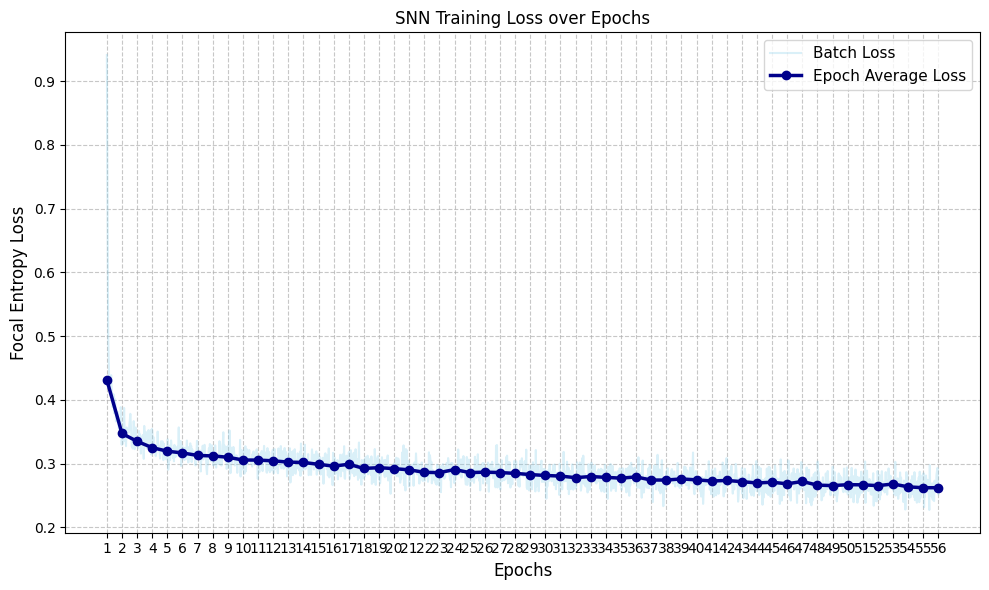

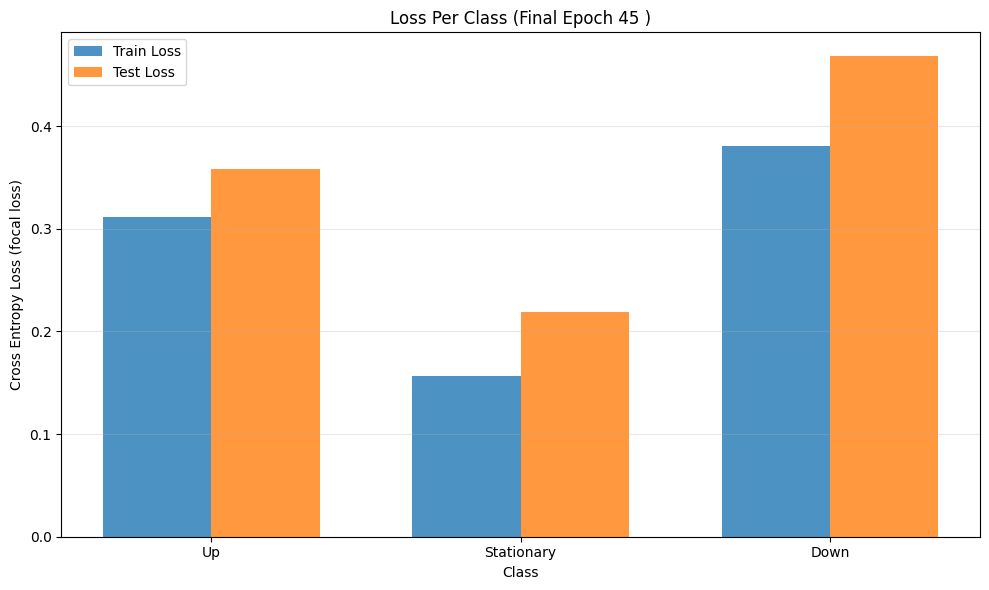

train loss per class: ['0.3112', '0.1566', '0.3807']
test loss per class: ['0.3585', '0.2186', '0.4680']
train per-class accuracy: [0.6740935  0.59016854 0.66503906]
test per-class accuracy: [0.5936575 0.4688716 0.5303371]
train overall: 0.6431 ** test overall: 0.5310


In [9]:
# visualizing results
import matplotlib.pyplot as plt
import numpy as np

batches_per_epoch = len(train_loader)
total_epochs = len(loss_hist) // batches_per_epoch
# average loss per epoch
loss_array = np.array(loss_hist)[:total_epochs * batches_per_epoch].reshape(total_epochs, batches_per_epoch)

epoch_losses = loss_array.mean(axis=1)
epochs_x = np.arange(1, total_epochs + 1)
batches_x = np.linspace(1, total_epochs, len(loss_hist))

plt.figure(figsize=(10, 6))
plt.plot(batches_x, loss_hist, color='skyblue', alpha=0.3, label='Batch Loss')
plt.plot(epochs_x, epoch_losses, color='darkblue', linewidth=2.5, marker='o', label='Epoch Average Loss')

plt.title("SNN Training Loss over Epochs", fontsize=12)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Focal Entropy Loss", fontsize=12)
plt.xticks(epochs_x)  
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc="upper right", fontsize=11)
plt.tight_layout()

plt.show()

### The testing and ensuration
train_per_class = per_class_accuracy(train_loader, net, device)
test_per_class = per_class_accuracy(test_loader, net, device)
plot_loss_per_class(train_loader, test_loader, net, loss_fn, device, epoch=45)

print(f"train per-class accuracy: {train_per_class}")
print(f"test per-class accuracy: {test_per_class}")
print(f"train overall: {train_per_class.mean():.4f} ** test overall: {test_per_class.mean():.4f}")

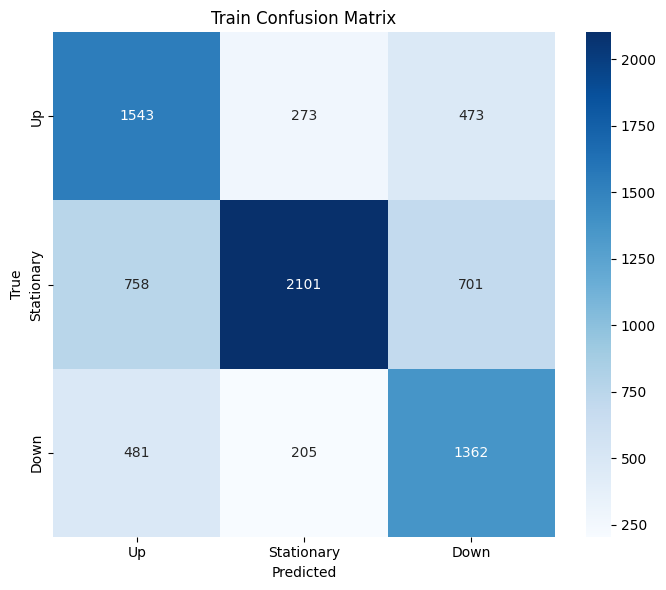


Train Classification Report:
              precision    recall  f1-score   support

          Up     0.5546    0.6741    0.6086      2289
  Stationary     0.8147    0.5902    0.6845      3560
        Down     0.5371    0.6650    0.5942      2048

    accuracy                         0.6339      7897
   macro avg     0.6355    0.6431    0.6291      7897
weighted avg     0.6673    0.6339    0.6391      7897

Macro F1:    0.6291
Weighted F1: 0.6391


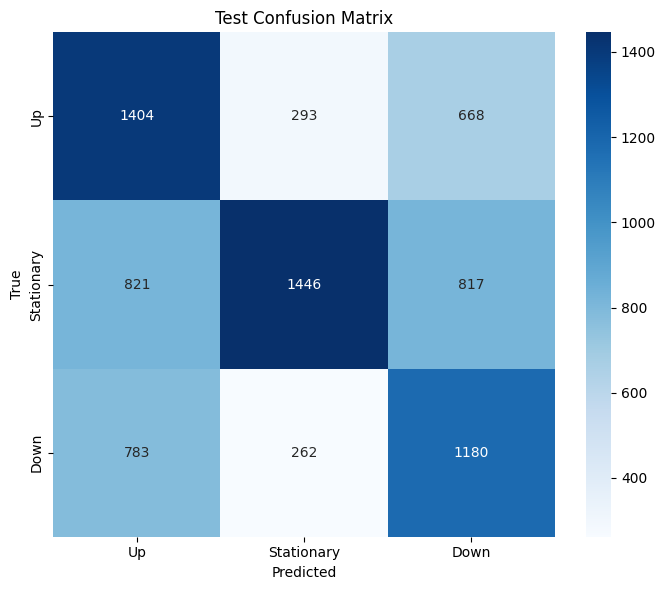


Test Classification Report:
              precision    recall  f1-score   support

          Up     0.4668    0.5937    0.5226      2365
  Stationary     0.7226    0.4689    0.5687      3084
        Down     0.4428    0.5303    0.4826      2225

    accuracy                         0.5251      7674
   macro avg     0.5441    0.5310    0.5247      7674
weighted avg     0.5626    0.5251    0.5296      7674

Macro F1:    0.5247
Weighted F1: 0.5296


In [10]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def get_all_predictions(data_loader, net, device):
    net.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for data, targets in data_loader:
            data = data.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).long()
            logits = net(data)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())
    return torch.cat(all_targets).numpy(), torch.cat(all_preds).numpy()


def evaluate_full(data_loader, net, device, split_name="Test"):
    y_true, y_pred = get_all_predictions(data_loader, net, device)
    
    class_names = ['Up', 'Stationary', 'Down']
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{split_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()
    
    # Full classification report (precision, recall, F1 per class)
    report = classification_report(y_true, y_pred, labels=[0, 1, 2],
                                     target_names=class_names, digits=4)
    print(f"\n{split_name} Classification Report:")
    print(report)
    
    # Macro and weighted F1 (single numbers for comparing against the paper)
    macro_f1 = f1_score(y_true, y_pred, labels=[0, 1, 2], average='macro')
    weighted_f1 = f1_score(y_true, y_pred, labels=[0, 1, 2], average='weighted')
    print(f"Macro F1:    {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")
    
    return cm, report, macro_f1, weighted_f1


# Run on both splits
print("="*60)
train_cm, train_report, train_macro_f1, train_weighted_f1 = evaluate_full(
    train_loader, net, device, split_name="Train"
)

print("="*60)
test_cm, test_report, test_macro_f1, test_weighted_f1 = evaluate_full(
    test_loader, net, device, split_name="Test"
)

[0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 0 0 1 0 0 0 0 0 2 2 0 0 0 0 2 2 2 2 2 2 2 2 0 0 2 2 2
 2 2 2 2 0 0 1 0 0 0 0 0 0 0 0 0 2 0 0 2 2 2 0 2 2 0 0 2 2 2 2 0 0 0 0 0 0
 0 0 2 2 1 1 0 1 1 0 0 2 0 0 0 2 2 2 0 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 2 0 0
 2 0 0 0 0 0 0 0 0 0 1 1 2 0 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2
 2 0 0 2 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


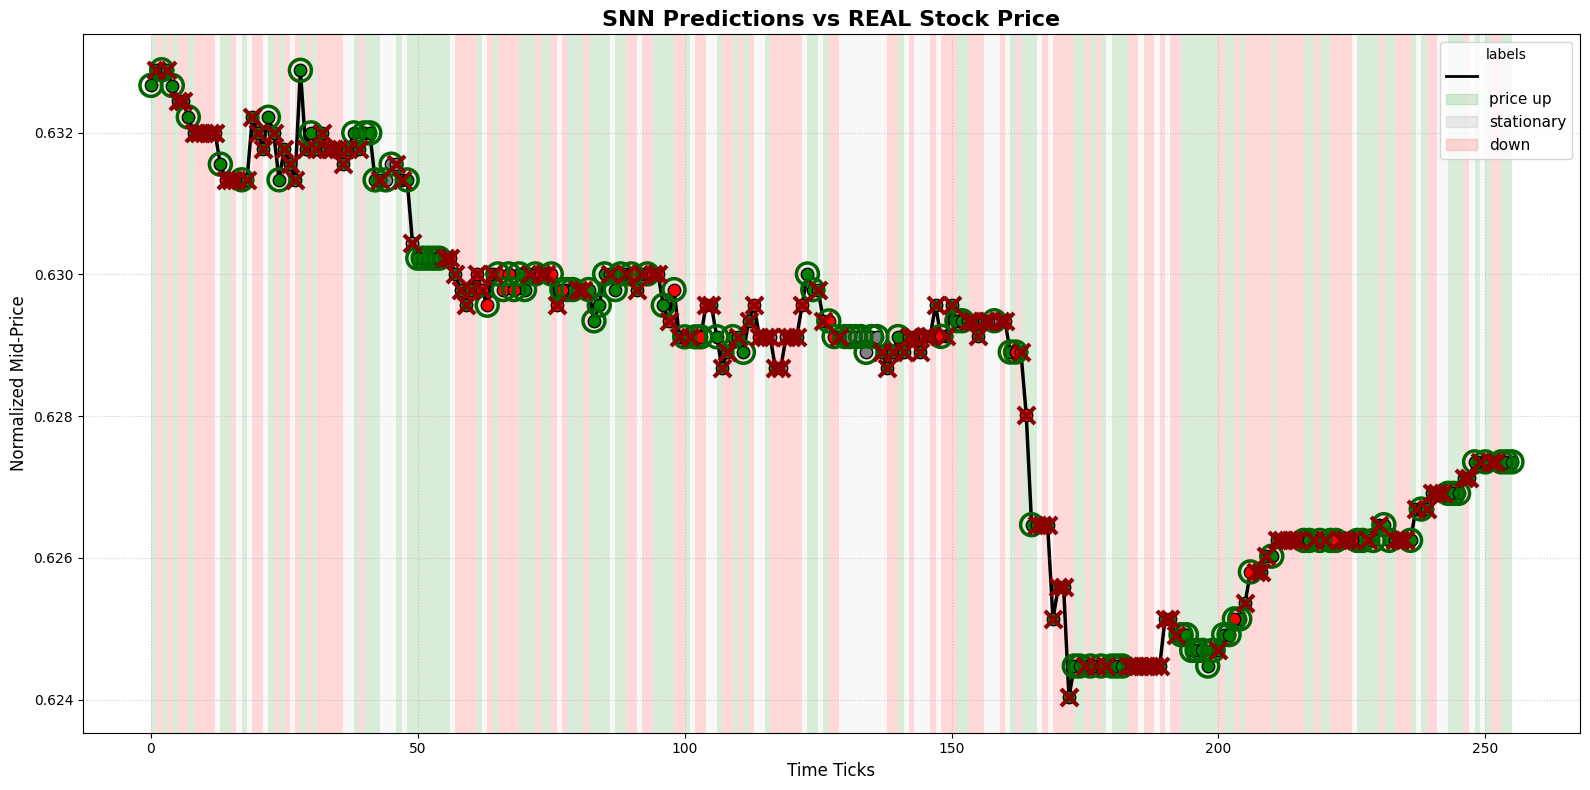


Tick   | P_t        | P_t+1      | label         | Target   | Prediction | Status  
0      | 0.63267    | 0.63289    | class[0]      | 0        | 0          | correct
1      | 0.63289    | 0.63289    | class[1]      | 2        | 0          | wrong * target mismatch
2      | 0.63289    | 0.63289    | class[1]      | 0        | 0          | correct * target mismatch
3      | 0.63289    | 0.63267    | class[2]      | 2        | 0          | wrong
4      | 0.63267    | 0.63244    | class[2]      | 0        | 0          | correct * target mismatch
5      | 0.63244    | 0.63244    | class[1]      | 2        | 0          | wrong * target mismatch
6      | 0.63244    | 0.63222    | class[2]      | 2        | 0          | wrong
7      | 0.63222    | 0.63200    | class[2]      | 0        | 0          | correct * target mismatch
8      | 0.63200    | 0.63200    | class[1]      | 2        | 0          | wrong * target mismatch
9      | 0.63200    | 0.63200    | class[1]      | 2        | 0       

In [11]:
net.eval()
with torch.no_grad():
    data, targets = next(iter(test_loader))
    data = data.to(device)
    targets = targets.cpu().numpy()
    
    logits = net(data)
    preds = logits.argmax(dim=1).cpu().numpy()


raw_data = np.loadtxt(test_file) 
raw_ask = raw_data[0, :]
raw_bid = raw_data[2, :]
raw_mid_prices = (raw_ask + raw_bid) / 2

limit = min(3000, len(targets))
slice_targets = targets[:limit]
slice_preds = preds[:limit]
time_steps = np.arange(limit)
 
correct_mask = (slice_preds == slice_targets)
wrong_mask = (slice_preds != slice_targets)

start_idx = window_size - 1
slice_prices = raw_mid_prices[start_idx : start_idx + limit]

plt.figure(figsize=(16, 8))
color_map = {0: 'green', 1: 'gray', 2: 'red'}


for i in range(len(time_steps) - 1):
    label = slice_targets[i]
    if label == 0:
        color, alpha = 'green', 0.15
    elif label == 1:
        color, alpha = 'gray', 0.05
    elif label == 2:
        color, alpha = 'red', 0.15
    plt.axvspan(time_steps[i], time_steps[i+1], color=color, alpha=alpha, lw=0)
    

plt.plot(time_steps, slice_prices, color='black', linewidth=2.5, zorder=1, label='Mid-Price')

for c in range(3):
    mask = slice_preds == c
    if np.any(mask):
        plt.scatter(time_steps[mask], slice_prices[mask], 
                    color=color_map[c], s=80, edgecolor='black', zorder=2, 
                    label=f'SNN Predicted: Class {c}', alpha=1)
        
if np.any(correct_mask):
    plt.scatter(time_steps[correct_mask], slice_prices[correct_mask], color='none',
                edgecolor='darkgreen', marker='o', s=250, linewidths=2.5, zorder=3, label='Prediction: CORRECT')

# Dark red 'X' markers for wrong predictions
if np.any(wrong_mask):
    plt.scatter(time_steps[wrong_mask], slice_prices[wrong_mask], color='darkred',
                marker='x', s=150, linewidths=3, zorder=4, label='Prediction: WRONG')

print(slice_preds)
plt.title("SNN Predictions vs REAL Stock Price", fontsize=16, fontweight='bold')
plt.xlabel("Time Ticks", fontsize=12)
plt.ylabel("Normalized Mid-Price", fontsize=12)
plt.ylim(slice_prices.min() - 0.0005, slice_prices.max() + 0.0005) 


# Legend
true_up = mpatches.Patch(color='green', alpha=0.15, label='price up')
true_flat = mpatches.Patch(color='gray', alpha=0.15, label='stationary')
true_down = mpatches.Patch(color='red', alpha=0.15, label='down')
plt.legend(handles=[plt.Line2D([0], [0], color='black', lw=2), true_up, true_flat, true_down], 
           fontsize=11, title="labels")

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n" + "="*85)
print(f"{'Tick':<6} | {'P_t':<10} | {'P_t+1':<10} | {'label':<13} | {'Target':<8} | {'Prediction':<10} | {'Status':<8}")
print("="*85)

# We loop up to limit - 1 because we need the 'next' price tick to calculate movement
for i in range(limit - 1):
    current_p = slice_prices[i]
    next_p = slice_prices[i+1]
    
    # Calculate the physical movement direction
    if next_p > current_p:
        actual_move = "class[0]"
    elif next_p < current_p:
        actual_move = "class[2]"
    else:
        actual_move = "class[1]"
        
    target_val = slice_targets[i]
    pred_val = slice_preds[i]
    
    # Determine programmatic correctness status
    status = "correct" if target_val == pred_val else "wrong"
    
    # Highlight cases where code says OK but target doesn't match the physical move
    # (Assuming Class 0=Up, Class 1=Flat, Class 2=Down)
    is_target_buggy = False
    if (actual_move.startswith("class[0]") and target_val != 0) or \
       (actual_move.startswith("class[1]") and target_val != 1) or \
       (actual_move.startswith("class[2]") and target_val != 2):
        status += " * target mismatch"

    print(f"{i:<6} | {current_p:<10.5f} | {next_p:<10.5f} | {actual_move:<13} | {target_val:<8} | {pred_val:<10} | {status}")

print("="*85)
correct = np.sum(slice_preds == slice_targets)
wrong = np.sum(slice_preds != slice_targets )
print(slice_preds)
print(f"total ticks: {limit}")
print(f"correct {correct} ({(correct/limit)*100:.1f}%)")
print(f'wrong {wrong}')
print(f"total ticks {len(slice_labels)}")


--- Running Memristor Crossbar Hardware Validation Sweep ---
SAF: 0.0% | Noise: 0.0% | Acc: 48.13% ± 0.00%
SAF: 0.0% | Noise: 2.0% | Acc: 48.35% ± 0.36%
SAF: 0.0% | Noise: 5.0% | Acc: 48.19% ± 0.26%
SAF: 0.0% | Noise: 8.0% | Acc: 47.83% ± 0.14%
SAF: 0.0% | Noise: 12.0% | Acc: 47.41% ± 0.53%
SAF: 1.0% | Noise: 0.0% | Acc: 47.89% ± 0.67%
SAF: 1.0% | Noise: 2.0% | Acc: 48.54% ± 2.29%
SAF: 1.0% | Noise: 5.0% | Acc: 46.11% ± 2.78%
SAF: 1.0% | Noise: 8.0% | Acc: 47.06% ± 1.15%
SAF: 1.0% | Noise: 12.0% | Acc: 45.75% ± 1.05%
SAF: 3.0% | Noise: 0.0% | Acc: 47.48% ± 2.39%
SAF: 3.0% | Noise: 2.0% | Acc: 42.90% ± 1.98%
SAF: 3.0% | Noise: 5.0% | Acc: 44.26% ± 2.15%
SAF: 3.0% | Noise: 8.0% | Acc: 43.57% ± 2.00%
SAF: 3.0% | Noise: 12.0% | Acc: 43.66% ± 0.94%
SAF: 5.0% | Noise: 0.0% | Acc: 45.82% ± 1.83%
SAF: 5.0% | Noise: 2.0% | Acc: 42.25% ± 1.68%
SAF: 5.0% | Noise: 5.0% | Acc: 43.49% ± 1.77%
SAF: 5.0% | Noise: 8.0% | Acc: 40.89% ± 2.48%
SAF: 5.0% | Noise: 12.0% | Acc: 42.48% ± 1.73%
SAF: 10.0% | N

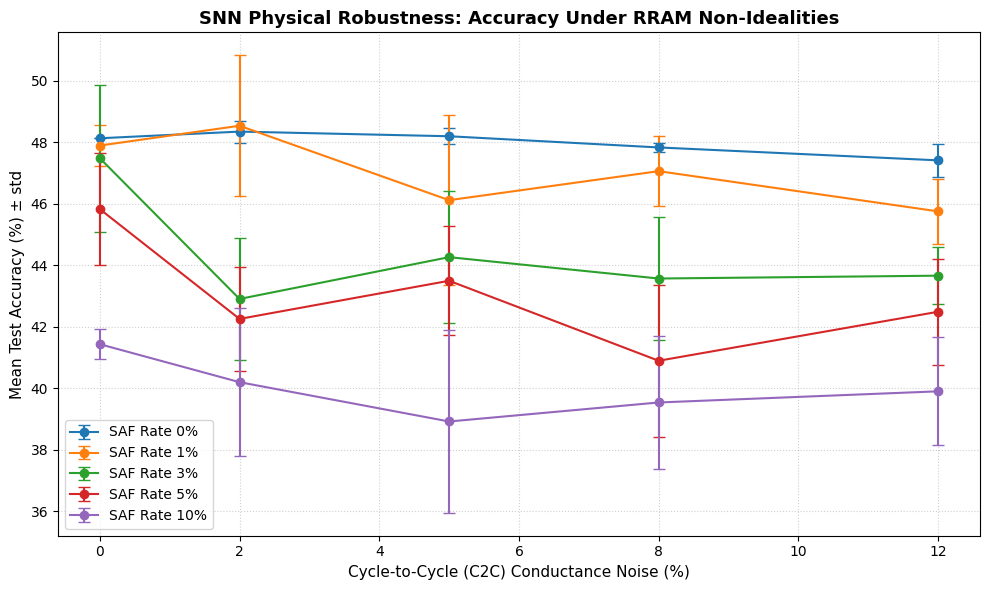

In [12]:
def validate_hardware_robustness(model_path, test_loader, device, n_trials=5):
    noise_sweeps = [0.0, 0.02, 0.05, 0.08, 0.12]
    saf_sweeps = [0.0, 0.01, 0.03, 0.05, 0.10]

    eval_net = HFT_Net_Optimized(num_levels=16, saf_rate=0.0, noise_std=0.0).to(device)
    eval_net.load_state_dict(torch.load(model_path, map_location=device))
    eval_net.eval()

    results = {}
    print("\n--- Running Memristor Crossbar Hardware Validation Sweep ---")
    for saf in saf_sweeps:
        results[saf] = {'mean': [], 'std': []}
        for noise in noise_sweeps:
            trial_accs = []
            for trial in range(n_trials):
                for name, module in eval_net.named_modules():
                    if isinstance(module, MemristorCrossbarLinear):
                        module.generate_saf_masks(saf)  # fresh defect draw each trial
                        module.noise_std = noise
                        module.force_noise_eval = True
                accs = per_class_accuracy(test_loader, eval_net, device)
                trial_accs.append(accs.mean())

            mean_acc = np.mean(trial_accs)
            std_acc = np.std(trial_accs)
            results[saf]['mean'].append(mean_acc)
            results[saf]['std'].append(std_acc)
            print(f"SAF: {saf*100:.1f}% | Noise: {noise*100:.1f}% | "
                  f"Acc: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")

    plt.figure(figsize=(10, 6))
    for saf, data in results.items():
        means = [a*100 for a in data['mean']]
        stds = [s*100 for s in data['std']]
        plt.errorbar([n*100 for n in noise_sweeps], means, yerr=stds,
                     marker='o', capsize=4, label=f'SAF Rate {saf*100:.0f}%')

    plt.title("SNN Physical Robustness: Accuracy Under RRAM Non-Idealities", fontsize=13, fontweight='bold')
    plt.xlabel("Cycle-to-Cycle (C2C) Conductance Noise (%)", fontsize=11)
    plt.ylabel("Mean Test Accuracy (%) ± std", fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results

results = validate_hardware_robustness('best_model.pt', test_loader, device, n_trials=5)

In [13]:
import torch
import numpy as np

# 1. Define the energy cost per operation (in Picojoules)
E_MAC = 4.6  # Energy of a standard GPU MAC operation
E_SOP = 0.1  # Energy of an analog Memristor SOP 

def calculate_energy_efficiency(test_loader, model_path, device):
    print("--- Running Neuromorphic Energy Profiler ---")
    
    # We redefine the model locally just to capture the spikes in the forward pass
    class EnergyProfilerNet(HFT_Net_Optimized):
        def forward(self, x):
            x = x.permute(1, 0, 2)
            mem1 = self.lif1.init_leaky()
            mem2 = self.lif2.init_leaky()
            
            total_spikes_l1 = 0
            total_spikes_l2 = 0
            
            for step in range(x.shape[0]):
                # Input layer: x is already delta-encoded spikes (0s and 1s)
                # Hidden layer spikes
                cur1 = self.fc1(x[step])
                spk1, mem1 = self.lif1(cur1, mem1)
                total_spikes_l1 += spk1.sum().item()
                
                # Output layer spikes
                cur2 = self.fc2(spk1)
                spk2, mem2 = self.lif2(cur2, mem2)
                total_spikes_l2 += spk2.sum().item()
                
            return total_spikes_l1, total_spikes_l2

    # Load your peak trained weights
    profiler = EnergyProfilerNet(num_levels=16, saf_rate=0.0, noise_std=0.0).to(device)
    profiler.load_state_dict(torch.load(model_path, map_location=device))
    profiler.eval()

    # Grab ONE batch of unseen market data
    data, _ = next(iter(test_loader))
    data = data.to(device)
    batch_size = data.shape[0]
    time_steps = data.shape[1]
    
    # Run the profiler to count the exact number of spikes
    with torch.no_grad():
        spikes_l1, spikes_l2 = profiler(data)
        
    # Average spikes per single market sequence
    avg_spikes_l1 = spikes_l1 / batch_size
    avg_spikes_l2 = spikes_l2 / batch_size
    total_avg_spikes = avg_spikes_l1 + avg_spikes_l2
    
    # --- THEORETICAL MAC CALCULATION (STANDARD ANN) ---
    # Layer 1: 288 inputs * 128 hidden neurons
    # Layer 2: 128 hidden * 3 output neurons
    macs_per_step = (288 * 128) + (128 * 3)
    total_macs = macs_per_step * time_steps
    
    ann_energy = total_macs * E_MAC
    snn_energy = total_avg_spikes * E_SOP
    
    savings = ann_energy / snn_energy

    print(f"\n[Sequence Analysis: 1 Market Window ({time_steps} ticks)]")
    print(f"Standard ANN Total MACs required:  {total_macs:,.0f}")
    print(f"Your MSNN Total Spikes generated:  {total_avg_spikes:,.0f}")
    
    print(f"\n[Energy Consumption]")
    print(f"Standard Digital ANN: {ann_energy:,.2f} pJ")
    print(f"Your Analog MSNN:     {snn_energy:,.2f} pJ")
    print(f"\n>>> RESULT: Your MSNN is {savings:,.1f}x more energy efficient than a standard Neural Network.")

# Run the profiler using your best checkpoint
calculate_energy_efficiency(test_loader, 'best_model.pt', device)

--- Running Neuromorphic Energy Profiler ---

[Sequence Analysis: 1 Market Window (30 ticks)]
Standard ANN Total MACs required:  1,117,440
Your MSNN Total Spikes generated:  221

[Energy Consumption]
Standard Digital ANN: 5,140,224.00 pJ
Your Analog MSNN:     22.07 pJ

>>> RESULT: Your MSNN is 232,918.7x more energy efficient than a standard Neural Network.


In [ ]:
import torch
import os
import subprocess

# 1. We calculate the sparsity from your network
def get_msnn_sparsity(test_loader, model_path, device):
    print("--- Calculating MSNN Spike Sparsity ---")
    
    # Load your model (assuming HFT_Net_Optimized is defined in your script)
    net = HFT_Net_Optimized(num_levels=16, saf_rate=0.0, noise_std=0.0).to(device)
    net.load_state_dict(torch.load(model_path, map_location=device))
    net.eval()

    data, _ = next(iter(test_loader))
    data = data.to(device)
    x = data.permute(1, 0, 2)
    
    mem1 = net.lif1.init_leaky()
    
    total_l1_inputs = 0
    total_l1_spikes = 0
    total_l2_inputs = 0
    total_l2_spikes = 0
    
    with torch.no_grad():
        for step in range(x.shape[0]):
            # Layer 1
            l1_in = x[step]
            total_l1_inputs += l1_in.numel()
            total_l1_spikes += l1_in.sum().item()
            
            cur1 = net.fc1(l1_in)
            spk1, mem1 = net.lif1(cur1, mem1)
            
            # Layer 2
            total_l2_inputs += spk1.numel()
            total_l2_spikes += spk1.sum().item()

    # Calculate Activity Rate (Sparsity Percentage)
    activity_L1 = total_l1_spikes / total_l1_inputs if total_l1_inputs > 0 else 0.0
    activity_L2 = total_l2_spikes / total_l2_inputs if total_l2_inputs > 0 else 0.0
    
    print(f"Layer 1 Activity Rate: {activity_L1:.4f} ({activity_L1*100:.2f}% active)")
    print(f"Layer 2 Activity Rate: {activity_L2:.4f} ({activity_L2*100:.2f}% active)")
    
    return activity_L1, activity_L2

# 2. Extract Sparsity
act_l1, act_l2 = get_msnn_sparsity(test_loader, 'best_model.pt', device)

# 3. Fire NeuroSim directly from Python
print("\n--- Booting NeuroSim C++ Engine ---")

# NeuroSim Arguments based on your main.cpp:
# ./main [Epochs] [Network.csv] [WeightPrecision] [InputPrecision] [L1_Act1] [L1_Act2] [L1_Act3] [L1_Act4] [L2_Act1] ...
weight_precision = "4" # 4-bit memristors
input_precision = "1"  # 1-bit binary spikes

# We pass the sparsity activity rate to the 4 variables NeuroSim expects per layer
command = [
    "/kaggle/input/datasets/firmwired/vvvvvv/main.exe", "1",  "/kaggle/input/datasets/firmwired/netwoe/NetWork.csv", weight_precision, input_precision,
    str(act_l1), str(act_l1), "0", "0",  # Layer 1 forward activity (backprop is 0)
    str(act_l2), str(act_l2), "0", "0"   # Layer 2 forward activity (backprop is 0)
]

print("Executing Command: " + " ".join(command))
subprocess.run(command)

--- Calculating MSNN Spike Sparsity ---
Layer 1 Activity Rate: 0.1224 (12.24% active)
Layer 2 Activity Rate: 0.0569 (5.69% active)

--- Booting NeuroSim C++ Engine ---
Executing Command: main.exe 1 NetWork.csv 4 1 0.12240035445601852 0.12240035445601852 0 0 0.056885782877604166 0.056885782877604166 0 0


FileNotFoundError: [Errno 2] No such file or directory: 'main.exe'